# Fama-French + VIX Market Upside Prediction
## Logistic Regression | FF4 Factors + VIX | 1990–Present
**Target:** P(market gains >=X% at any point within next 63 trading days)

| Feature | Source | Intuition |
|---|---|---|
| `Mkt-RF` | FF daily | Market excess return |
| `SMB` | FF daily | Small-minus-big — risk appetite |
| `HML` | FF daily | Value vs. growth rotation |
| `Mom` | FF daily | Prior 12m–1m return spread |
| `RF` | FF daily | Risk-free rate — monetary tightening |
| `VIX` | FRED VIXCLS | Implied volatility — fear gauge |

> **Training window:** user-selected start (year + month) + duration (36–60 months).
> **Evaluation:** out-of-sample on all data **after** the training window.
> Features are raw + 5-day + 21-day rolling means, lagged 1 day (no lookahead).
> Model: `LogisticRegression(class_weight='balanced', penalty='l1')`

In [ ]:
# --- 1. SETUP ---
import pandas as pd
import numpy as np
import io, zipfile, requests, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import ipywidgets as widgets
from IPython.display import display, clear_output

print("✅ Libraries loaded")

✅ Libraries loaded


In [ ]:
# --- 2. FETCH FF4 DAILY + VIX FROM FRED ---

def fetch_ff_zip(url: str) -> pd.DataFrame:
    """Download Ken French ZIP, parse robustly regardless of CRSP header lines."""
    hdrs = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
        'Referer': 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html'
    }
    resp = requests.get(url, headers=hdrs, timeout=30)
    resp.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    csv_name = [n for n in z.namelist() if n.upper().endswith('.CSV')][0]
    raw = z.read(csv_name).decode('latin-1')
    lines = raw.splitlines()

    date_re = re.compile(r'^\s*\d{8}\s*,')
    first_data_idx = None
    for i, line in enumerate(lines):
        if date_re.match(line):
            first_data_idx = i
            header_row_idx = i - 1
            break
    if first_data_idx is None:
        raise ValueError("No YYYYMMDD rows found in FF CSV.")

    col_header = lines[header_row_idx]
    data_lines = [col_header]
    for line in lines[first_data_idx:]:
        if date_re.match(line):
            data_lines.append(line)
        elif line.strip() == '':
            continue
        else:
            break

    df = pd.read_csv(io.StringIO('\n'.join(data_lines)), index_col=0)
    df.columns = [c.strip() for c in df.columns]
    df.index = pd.to_datetime(df.index.astype(str).str.strip(), format='%Y%m%d')
    df.index.name = 'Date'
    df = df.apply(pd.to_numeric, errors='coerce') / 100
    return df


def fetch_vix() -> pd.Series:
    """Download daily VIX from FRED (VIXCLS). Returns a Series indexed by date."""
    url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text), index_col=0, parse_dates=True)
    df.columns = ['VIX']
    df['VIX'] = pd.to_numeric(df['VIX'], errors='coerce')
    return df['VIX'].dropna()


URL_FF3 = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip'
URL_MOM = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip'

print("Fetching FF3 daily…")
ff3 = fetch_ff_zip(URL_FF3)
print(f"  FF3: {ff3.shape}  cols: {ff3.columns.tolist()}")

print("Fetching Momentum daily…")
mom = fetch_ff_zip(URL_MOM)
print(f"  MOM: {mom.shape}  cols: {mom.columns.tolist()}")

print("Fetching VIX from FRED…")
vix = fetch_vix()
print(f"  VIX: {len(vix):,} obs  ({vix.index[0].date()} → {vix.index[-1].date()})")

# Merge all three; VIX starts ~1990 so that becomes the effective floor
ff = ff3.join(mom, how='inner').join(vix, how='inner')
ff = ff.loc['1990-01-01':].dropna()

print(f"\n✅ FF4 + VIX panel: {ff.shape[0]:,} daily obs  ({ff.index[0].date()} → {ff.index[-1].date()})")
display(ff.head(3))

# Store column name references globally
MKT_RF_COL = [c for c in ff.columns if 'mkt' in c.lower() or 'rm' in c.lower()][0]
SMB_COL    = [c for c in ff.columns if 'smb'  in c.lower()][0]
HML_COL    = [c for c in ff.columns if 'hml'  in c.lower()][0]
RF_COL     = [c for c in ff.columns if 'rf'   in c.lower() and 'mkt' not in c.lower()][0]
MOM_COL    = [c for c in ff.columns if 'mom'  in c.lower() or 'wml' in c.lower()][0]
VIX_COL    = 'VIX'
print(f"\nColumn map → Mkt-RF: '{MKT_RF_COL}' | SMB: '{SMB_COL}' | HML: '{HML_COL}' | RF: '{RF_COL}' | MOM: '{MOM_COL}' | VIX: '{VIX_COL}'")

Fetching FF3 daily…
  FF3: (26190, 4)  cols: ['Mkt-RF', 'SMB', 'HML', 'RF']
Fetching Momentum daily…
  MOM: (26089, 1)  cols: ['Mom']
Fetching VIX from FRED…
  VIX: 9,169 obs  (1990-01-02 → 2026-04-21)

✅ FF4 + VIX panel: 9,103 daily obs  (1990-01-02 → 2026-02-27)


,Mkt-RF,SMB,HML,RF,Mom,VIX
1990-01-02,0.0144,-0.0069,-0.0006,0.0003,-0.0108,17.24
1990-01-03,-0.0006,0.0073,-0.0026,0.0003,-0.0031,18.19
1990-01-04,-0.0071,0.0042,-0.0024,0.0003,-0.0034,19.22



Column map → Mkt-RF: 'Mkt-RF' | SMB: 'SMB' | HML: 'HML' | RF: 'RF' | MOM: 'Mom' | VIX: 'VIX'


In [ ]:
# --- 3. FEATURE ENGINEERING (upside target constructed at runtime per gain level) ---

WINDOW = 63   # ~3 calendar months in trading days

# Total market return (Mkt-RF + RF)
ff['Mkt'] = ff[MKT_RF_COL] + ff[RF_COL]
ff['Mkt_idx'] = (1 + ff['Mkt']).cumprod()

# Feature matrix: raw + 5d + 21d rolling means, lagged 1 day
RAW_COLS = {
    MKT_RF_COL: 'Mkt_RF', SMB_COL: 'SMB', HML_COL: 'HML',
    MOM_COL: 'Mom', RF_COL: 'RF', VIX_COL: 'VIX'
}
for raw_col, nice in RAW_COLS.items():
    ff[f'{nice}_raw'] = ff[raw_col]
    ff[f'{nice}_5d']  = ff[raw_col].rolling(5).mean()
    ff[f'{nice}_21d'] = ff[raw_col].rolling(21).mean()

FEAT_COLS = [c for c in ff.columns if c.endswith(('_raw','_5d','_21d'))]

# Lag all features 1 day (no lookahead)
for fc in FEAT_COLS:
    ff[fc] = ff[fc].shift(1)

# ff_base: all rows with valid features — target added at runtime
ff_base = ff.dropna(subset=FEAT_COLS).copy()

print(f"Base panel ready: {len(ff_base):,} obs  ({ff_base.index[0].date()} -> {ff_base.index[-1].date()})")
print(f"Features ({len(FEAT_COLS)}): {FEAT_COLS}")
print("Target (UpsideEvent) constructed at runtime based on selected gain level.")


Base panel ready: 9,082 obs  (1990-01-31 -> 2026-02-27)
Features (18): ['Mkt_RF_raw', 'Mkt_RF_5d', 'Mkt_RF_21d', 'SMB_raw', 'SMB_5d', 'SMB_21d', 'HML_raw', 'HML_5d', 'HML_21d', 'Mom_raw', 'Mom_5d', 'Mom_21d', 'RF_raw', 'RF_5d', 'RF_21d', 'VIX_raw', 'VIX_5d', 'VIX_21d']
Target (UpsideEvent) constructed at runtime based on selected gain level.


In [ ]:
# --- 4. WINDOW CONTROLS + DASHBOARD (UPSIDE MODEL) ---
import datetime, calendar
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

C_TN = '#f4a7a7'
C_FP = '#c0392b'
C_FN = '#a8d5b0'
C_TP = '#27ae60'

panel_start = ff_base.index[0]
panel_end   = ff_base.index[-1]
min_year    = panel_start.year
max_year    = panel_end.year - 3

year_widget = widgets.Dropdown(
    options=list(range(min_year, max_year + 1)),
    value=1995,
    description='Start Year:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)
month_widget = widgets.Dropdown(
    options=[(datetime.date(2000, m, 1).strftime('%B'), m) for m in range(1, 13)],
    value=1,
    description='Start Month:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)
duration_slider = widgets.IntSlider(
    value=48, min=36, max=60, step=1,
    description='Duration (months):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='340px')
)
gain_input = widgets.BoundedFloatText(
    value=10.0, min=2.0, max=40.0, step=1.0,
    description='Gain Level (%):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='190px')
)
threshold_input = widgets.BoundedFloatText(
    value=0.30, min=0.05, max=0.95, step=0.01,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='190px')
)
run_button = widgets.Button(
    description='Run Model',
    button_style='primary',
    layout=widgets.Layout(width='140px', height='36px')
)
status_label = widgets.HTML(value='<i>Set parameters and click Run.</i>')
output_area  = widgets.Output()

ui = widgets.VBox([
    widgets.HBox([year_widget, month_widget, duration_slider]),
    widgets.HBox([gain_input, threshold_input, run_button]),
    status_label,
    output_area
])
display(ui)


def build_target(gain_level_pct):
    """
    Target = 1 if forward cumulative return exceeds +gain_level_pct
    at any point within the next WINDOW trading days.
    Forward return from day i to day j: (mkt_idx[j] / mkt_idx[i]) - 1
    """
    threshold = gain_level_pct / 100.0
    mkt_arr   = ff_base['Mkt_idx'].values
    n         = len(mkt_arr)
    target    = np.full(n, np.nan)
    for i in range(n - WINDOW):
        base        = mkt_arr[i]
        seg         = mkt_arr[i+1 : i + WINDOW]   # forward prices
        fwd_returns = (seg / base) - 1.0           # cumulative return from today
        target[i]   = 1 if fwd_returns.max() >= threshold else 0
    return target


def run_model(btn):
    yr         = year_widget.value
    mo         = month_widget.value
    dur        = duration_slider.value
    gain_level = gain_input.value
    thresh     = threshold_input.value

    train_start = pd.Timestamp(yr, mo, 1)
    end_mo   = mo + dur - 1
    end_yr   = yr + (end_mo - 1) // 12
    end_mo   = (end_mo - 1) % 12 + 1
    last_day = calendar.monthrange(end_yr, end_mo)[1]
    train_end  = pd.Timestamp(end_yr, end_mo, last_day)
    oos_start  = train_end + pd.offsets.BDay(1)

    status_label.value = (
        f'<b>Train:</b> {train_start.date()} -> {train_end.date()} ({dur}mo) &nbsp;|&nbsp; '
        f'<b>OOS:</b> {oos_start.date()} -> {ff_base.index[-1].date()} &nbsp;|&nbsp; '
        f'<b>Gain:</b> {gain_level:.0f}% &nbsp;|&nbsp; '
        f'<b>Thresh:</b> {thresh:.2f}'
    )

    with output_area:
        clear_output(wait=True)

        # ── Build upside target at runtime ────────────────────────────────
        print(f"Computing >={gain_level:.0f}% forward return labels...")
        target = build_target(gain_level)
        ff_model = ff_base.copy()
        ff_model['UpsideEvent'] = target
        ff_model = ff_model.dropna(subset=['UpsideEvent'])

        total_events = int(ff_model['UpsideEvent'].sum())
        print(f"Panel: {len(ff_model):,} obs | {total_events} upside events ({ff_model['UpsideEvent'].mean():.1%} base rate)")

        # ── Train / OOS split ─────────────────────────────────────────────
        train_mask = (ff_model.index >= train_start) & (ff_model.index <= train_end)
        oos_mask   = ff_model.index >= oos_start

        X_train = ff_model.loc[train_mask, FEAT_COLS].astype(float)
        y_train = ff_model.loc[train_mask, 'UpsideEvent'].astype(float)
        X_oos   = ff_model.loc[oos_mask,   FEAT_COLS].astype(float)
        y_oos   = ff_model.loc[oos_mask,   'UpsideEvent'].astype(float)

        if len(X_train) < 200:
            print(f"Training window too short ({len(X_train)} obs). Extend duration or adjust start.")
            return
        if len(X_oos) < 63:
            print(f"OOS window too short ({len(X_oos)} obs). Move start date earlier.")
            return
        n_events_train = int(y_train.sum())
        if n_events_train < 5:
            print(f"Only {n_events_train} upside events in training window. Try a wider window or lower gain level.")
            return

        print(f"Training: {len(X_train):,} obs | {n_events_train} events ({y_train.mean():.1%})")
        print(f"OOS:      {len(X_oos):,} obs  | {int(y_oos.sum())} events ({y_oos.mean():.1%})")

        # ── Fit ───────────────────────────────────────────────────────────
        clf = LogisticRegression(
            penalty='l1', solver='liblinear', C=20.0,
            class_weight='balanced', max_iter=1000, random_state=42
        )
        clf.fit(X_train, y_train)

        y_prob    = clf.predict_proba(X_oos)[:, 1]
        y_pred    = (y_prob >= thresh).astype(int)
        y_oos_arr = y_oos.values
        log_odds  = X_train.values @ clf.coef_[0] + clf.intercept_[0]

        label0     = 'No Rally'
        label1     = f'>={gain_level:.0f}% Rally'
        prob_label = f'P(>={gain_level:.0f}% Rally)'

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        ax_sig, ax_coef, ax_hist, ax_cm = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

        # ── A: Sigmoid ────────────────────────────────────────────────────
        z_range  = np.linspace(log_odds.min(), log_odds.max(), 300)
        p_range  = 1 / (1 + np.exp(-z_range))
        thresh_z = np.log(thresh / (1 - thresh))
        ax_sig.plot(z_range, p_range, color='steelblue', lw=2.5, label=prob_label)
        ax_sig.fill_between(z_range, p_range, alpha=0.08, color='steelblue')
        ax_sig.axhline(thresh, color='red', linestyle='--', lw=1.5,
                       label=f'Threshold = {thresh:.2f}')
        ax_sig.axvline(thresh_z, color='red', linestyle=':', lw=1, alpha=0.5)
        for z_pt in np.linspace(log_odds.min(), log_odds.max(), 10):
            p_pt = 1 / (1 + np.exp(-z_pt))
            ax_sig.annotate(f'{p_pt:.2f}', xy=(z_pt, p_pt),
                            fontsize=7, color='steelblue', ha='center', va='bottom')
        ax_sig.set_title('A.  Sigmoid — ' + prob_label + ' vs. Linear Score', fontweight='bold')
        ax_sig.set_xlabel('Linear Score:  z = b0 + b1*x1 + b2*x2 + ... + bn*xn')
        ax_sig.set_ylabel(prob_label)
        ax_sig.legend(fontsize=9)
        ax_sig.set_ylim(-0.03, 1.05)

        # ── B: Coefficients ───────────────────────────────────────────────
        coef_s  = pd.Series(clf.coef_[0], index=FEAT_COLS)
        coef_df = (pd.DataFrame({'Feature': coef_s.index, 'Coeff': coef_s.values})
                     .assign(AbsCoeff=lambda d: d['Coeff'].abs())
                     .nlargest(15, 'AbsCoeff')
                     .sort_values('Coeff'))
        colours_b = [C_TP if c > 0 else C_FP for c in coef_df['Coeff']]
        bars = ax_coef.barh(coef_df['Feature'], coef_df['Coeff'],
                            color=colours_b, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, coef_df['Coeff']):
            ax_coef.text(val + (0.01 if val >= 0 else -0.01),
                         bar.get_y() + bar.get_height()/2,
                         f'{val:.3f}', va='center',
                         ha='left' if val >= 0 else 'right', fontsize=7.5)
        ax_coef.axvline(0, color='black', linewidth=0.8)
        ax_coef.set_title('B.  Factor Weights (Log-Odds)  |  class_weight="balanced"', fontweight='bold')
        ax_coef.set_xlabel('Coefficient (log-odds)')
        ax_coef.set_ylabel('Feature')

        # ── C: Probability histogram ──────────────────────────────────────
        bin_edges = np.linspace(0, 1, 21)
        for actual, col_left, col_right, label in [
            (0, C_TN, C_FP, f'Actual 0 ({label0})'),
            (1, C_FN, C_TP, f'Actual 1 ({label1})')
        ]:
            probs_cls   = y_prob[y_oos_arr == actual]
            left_probs  = probs_cls[probs_cls <  thresh]
            right_probs = probs_cls[probs_cls >= thresh]
            ax_hist.hist(left_probs,  bins=bin_edges, color=col_left,
                         alpha=0.80, edgecolor=col_right, linewidth=1.2,
                         label=f'{label} — left of threshold')
            counts_l, _ = np.histogram(left_probs, bins=bin_edges)
            for count, edge in zip(counts_l, bin_edges[:-1]):
                if count > 0:
                    ax_hist.text(edge+0.025, count+0.3, str(count),
                                 ha='center', fontsize=7, color=col_right)
            ax_hist.hist(right_probs, bins=bin_edges, color=col_right,
                         alpha=0.55, edgecolor=col_right, linewidth=1.2,
                         label=f'{label} — right of threshold')
            counts_r, _ = np.histogram(right_probs, bins=bin_edges)
            for count, edge in zip(counts_r, bin_edges[:-1]):
                if count > 0:
                    ax_hist.text(edge+0.025, count+0.3, str(count),
                                 ha='center', fontsize=7, color=col_right)
        ax_hist.axvline(thresh, color='black', linestyle='--', lw=2,
                        label=f'Threshold = {thresh:.2f}')
        ax_hist.set_title('C.  Predicted Probability by Actual Outcome  [OOS]', fontweight='bold')
        ax_hist.set_xlabel('Predicted Probability — ' + prob_label)
        ax_hist.set_ylabel('Count')
        ax_hist.set_xlim(0, 1)
        ax_hist.legend(fontsize=8)

        # ── D: Confusion matrix ───────────────────────────────────────────
        cm_mat = confusion_matrix(y_oos_arr, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm_mat.ravel()
        n_obs = len(y_oos_arr)
        acc   = (tp + tn) / n_obs
        prec0 = tn / (tn + fn) if (tn + fn) > 0 else 0
        prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec0  = tn / (tn + fp) if (tn + fp) > 0 else 0
        rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0

        cell_colours = [[C_TN, C_FP], [C_FN, C_TP]]
        cell_values  = [[tn, fp], [fn, tp]]
        cell_labels  = [['True Neg','False Pos'],['False Neg','True Pos']]

        ax_cm.set_xlim(0, 2); ax_cm.set_ylim(0, 2.58); ax_cm.invert_yaxis()
        for r in range(2):
            for c in range(2):
                rect = mpatches.FancyBboxPatch(
                    (c+0.04, r+0.04), 0.92, 0.80,
                    boxstyle='round,pad=0.02',
                    facecolor=cell_colours[r][c], edgecolor='white', lw=2)
                ax_cm.add_patch(rect)
                count = cell_values[r][c]
                ax_cm.text(c+0.50, r+0.28, f'{count}', ha='center', va='center',
                           fontsize=24, fontweight='bold', color='white')
                ax_cm.text(c+0.50, r+0.52, f'({count/n_obs*100:.1f}%)', ha='center',
                           va='center', fontsize=11, color='white')
                ax_cm.text(c+0.50, r+0.72, cell_labels[r][c], ha='center',
                           va='center', fontsize=8.5, color='white', style='italic')

        ax_cm.text(1.0, 2.10,
                   f'Accuracy: {acc:.1%}     Base Rate: {y_oos_arr.mean():.1%}     N = {n_obs:,}',
                   ha='center', va='center', fontsize=9.5, fontweight='bold',
                   family='monospace',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='#d6d6d6',
                             edgecolor='#888888', lw=1.5))
        ax_cm.text(1.0, 2.42,
                   f'Precision — {label0} (0): {prec0:.1%}    {label1} (1): {prec1:.1%}\n'
                   f'Recall    — {label0} (0): {rec0:.1%}    {label1} (1): {rec1:.1%}',
                   ha='center', va='center', fontsize=9, family='monospace',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='#d6d6d6',
                             edgecolor='#888888', lw=1.5))

        ax_cm.set_xticks([0.5, 1.5])
        ax_cm.set_xticklabels([f'Predicted 0\n({label0})', f'Predicted 1\n({label1})'], fontsize=10)
        ax_cm.set_yticks([0.5, 1.5])
        ax_cm.set_yticklabels([f'Actual 0\n({label0})', f'Actual 1\n({label1})'], fontsize=10)
        ax_cm.xaxis.set_label_position('top'); ax_cm.xaxis.tick_top()
        ax_cm.set_xlabel('Predicted', fontsize=11, labelpad=8)
        ax_cm.set_ylabel('Actual', fontsize=11)
        ax_cm.set_title('D.  Confusion Matrix  [Out-of-Sample]', fontweight='bold', pad=30)
        ax_cm.tick_params(length=0)
        for spine in ax_cm.spines.values(): spine.set_visible(False)

        plt.suptitle(
            f'FF4+VIX Upside Logit  |  Gain>={gain_level:.0f}%  |  '
            f'Train: {train_start.date()} -> {train_end.date()} ({dur}mo)  |  '
            f'OOS: {oos_start.date()} -> {ff_base.index[-1].date()}  |  '
            f'Threshold={thresh:.2f}',
            fontsize=12, fontweight='bold', y=1.01
        )
        plt.tight_layout()
        plt.show()

        print(f"\n{'='*70}")
        print(f"  Gain Level: >={gain_level:.0f}%  |  Train: {train_start.date()} -> {train_end.date()}")
        print(f"  OOS: {oos_start.date()} -> {ff_base.index[-1].date()}  ({n_obs:,} obs)")
        print(f"  Threshold: {thresh:.2f}   Accuracy: {acc:.1%}   Base Rate: {y_oos_arr.mean():.1%}")
        print(f"  Precision — No Rally: {prec0:.1%}  |  Rally: {prec1:.1%}")
        print(f"  Recall    — No Rally: {rec0:.1%}  |  Rally: {rec1:.1%}")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
        print(f"{'='*70}")


run_button.on_click(run_model)


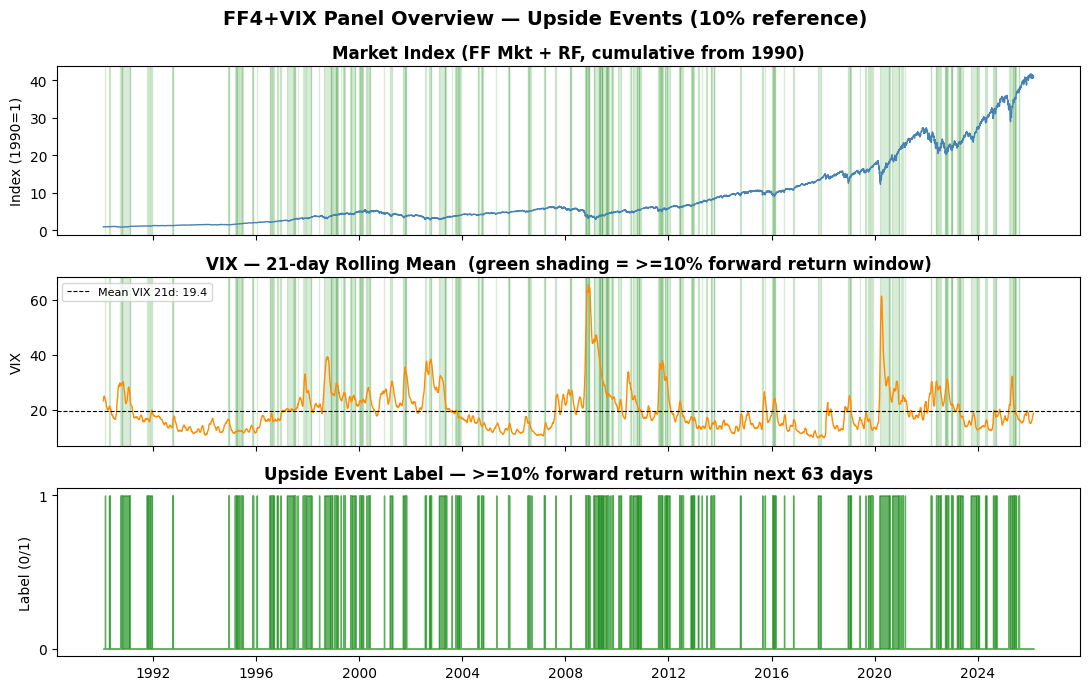

Notable rally windows in sample (1990-present):
  1995-99: Dot-com boom
  2003-07: Post-bust recovery
  2009-10: Post-GFC snapback
  2020:    COVID recovery rally
  2023-24: AI-driven bull run


In [ ]:
# --- 6. BONUS: UPSIDE EVENT TIMELINE ---
# Uses ff_base with a 10% forward return label for illustration.

import numpy as np

mkt_arr  = ff_base['Mkt_idx'].values
n        = len(mkt_arr)
tl_label = np.full(n, np.nan)
for i in range(n - WINDOW):
    base       = mkt_arr[i]
    seg        = mkt_arr[i+1 : i + WINDOW]
    fwd_rets   = (seg / base) - 1.0
    tl_label[i] = 1 if fwd_rets.max() >= 0.10 else 0

ff_base['UP10_label'] = tl_label

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(ff_base.index, ff_base['Mkt_idx'], color='steelblue', lw=1)
axes[0].set_title('Market Index (FF Mkt + RF, cumulative from 1990)', fontweight='bold')
axes[0].set_ylabel('Index (1990=1)')

# Shade upside event periods
in_event, start_e = False, None
for dt, val in ff_base['UP10_label'].items():
    if val == 1 and not in_event:
        in_event = True; start_e = dt
    elif val == 0 and in_event:
        for ax in axes[:2]:
            ax.axvspan(start_e, dt, alpha=0.15, color='green')
        in_event = False

axes[1].plot(ff_base.index, ff_base['VIX_21d'], color='darkorange', lw=1)
axes[1].axhline(ff_base['VIX_21d'].mean(), color='black', lw=0.8, linestyle='--',
                label=f"Mean VIX 21d: {ff_base['VIX_21d'].mean():.1f}")
axes[1].set_title('VIX — 21-day Rolling Mean  (green shading = >=10% forward return window)', fontweight='bold')
axes[1].set_ylabel('VIX')
axes[1].legend(fontsize=8)

axes[2].fill_between(ff_base.index, ff_base['UP10_label'].fillna(0),
                     step='pre', color='green', alpha=0.6)
axes[2].set_title('Upside Event Label — >=10% forward return within next 63 days',
                  fontweight='bold')
axes[2].set_ylabel('Label (0/1)')
axes[2].set_yticks([0, 1])

plt.suptitle('FF4+VIX Panel Overview — Upside Events (10% reference)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notable rally windows in sample (1990-present):")
print("  1995-99: Dot-com boom")
print("  2003-07: Post-bust recovery")
print("  2009-10: Post-GFC snapback")
print("  2020:    COVID recovery rally")
print("  2023-24: AI-driven bull run")
